In [1]:
pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
file_path = r"C:\Users\brent\OneDrive\Escritorio\ProyectoImpuestos\Laboral\Archivos\cuadros_tasas_indicadores_eph_12_25.xls"

df_raw = pd.read_excel(file_path, header=None)

df_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,Cuadro 1.1 Principales tasas del mercado labor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tasas,NaN,NaN,Total 31 aglomerados urbanos,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Año 2017,NaN,NaN,NaN,NaN,Año 2018,NaN,...,NaN,NaN,NaN,NaN,Año 2025,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,1° trimestre,2° trimestre,3° trimestre,4° trimestre,NaN,1° trimestre,2° trimestre,...,NaN,4° trimestre,NaN,NaN,1° trimestre,NaN,2° trimestre,NaN,3° trimestre,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Actividad,NaN,NaN,45.5,45.4,46.3,46.4,NaN,46.7,46.4,...,NaN,48.8,NaN,NaN,48.227256,NaN,48.1,NaN,48.6,NaN
7,Empleo,NaN,NaN,41.3,41.5,42.4,43,NaN,42.4,41.9,...,NaN,45.7,NaN,NaN,44.42232,(3),44.5,NaN,45.4,(3)
8,Desocupación abierta,NaN,NaN,9.2,8.7,8.3,7.2,NaN,9.1,9.6,...,(4),6.4,(4),NaN,7.889597,(3),7.6,NaN,6.6,(3)
9,Ocupados demandantes de empleo,NaN,NaN,14.1,14.7,15.4,14.7,NaN,15.3,16,...,(3) (4),16.6,(4),NaN,16.136594,NaN,17.1,NaN,16.1,NaN


In [7]:
xls = pd.ExcelFile(file_path)
xls.sheet_names

['Cuadro 1.1',
 'Cuadro 1.2 ',
 'Cuadro 1.3',
 'Cuadro 1.4 ',
 'Cuadro 1.5 ',
 'Cuadro 1.6 ',
 'Cuadro 1.7 ',
 'Cuadro 2.1',
 'Cuadro 3.1',
 'Cuadro 3.2',
 'Cuadro 3.3']

In [9]:
for sheet in xls.sheet_names:
    df_temp = pd.read_excel(file_path, sheet_name=sheet, header=None)
    contenido = df_temp.astype(str).apply(lambda x: x.str.contains("jubil", case=False)).any().any()
    
    if contenido:
        print("Posible hoja correcta:", sheet)

Posible hoja correcta: Cuadro 1.4 
Posible hoja correcta: Cuadro 1.5 


In [11]:
df_15 = pd.read_excel(
    file_path,
    sheet_name="Cuadro 1.5 ",
    header=None
)

df_15.head(30)

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,Cuadro 1.5 Caracterización de la población ocu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indicador,Total 31 aglomerados urbanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Año 2017,NaN,NaN,NaN,NaN,Año 2018,NaN,NaN,NaN,...,NaN,NaN,Año 2024,NaN,NaN,NaN,NaN,Año 2025,NaN,NaN
4,NaN,1° trimestre,2° trimestre,3° trimestre,4° trimestre,NaN,1° trimestre,2° trimestre,3° trimestre,4° trimestre,...,4º trimestre,NaN,1° trimestre,2º trimestre,3º trimestre,4º trimestre,NaN,1° trimestre,2° trimestre,3º trimestre
5,Población ocupada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Sexo y grupos de edad,100,100,100,100,NaN,100,100,100,100,...,100,NaN,100,100,100,100,NaN,100,100,100
7,Mujeres hasta 29 años,9.4,9.9,9.5,9.5,NaN,9.8,9.7,9.2,9.5,...,9.8,NaN,9.2,9.5,9.6,9.8,NaN,9.2,9.3,9.6
8,Mujeres de 30 a 64 años,31,31.3,31.4,31.4,NaN,31.5,32.2,32.7,32.2,...,32.9,NaN,33.6,33,32.7,33.1,NaN,32.8,33.1,32.6
9,Mujeres de 65 años y más,1.7,1.8,1.9,1.8,NaN,1.8,1.7,1.7,2,...,1.6,NaN,1.7,1.9,1.8,1.8,NaN,1.7,1.8,2.2


In [13]:
#
df_15[df_15.astype(str).apply(lambda x: x.str.contains("descuento", case=False)).any(axis=1)]

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
43,Con descuento jubilatorio (formal),66.7,66.2,65.6,65.7,NaN,66.1,65.7,65.7,64.7,...,64.3,NaN,64.3,63.6,63.3,63.9,NaN,63.7,62.3,63.3
44,Sin descuento jubilatorio (informal),33.3,33.8,34.4,34.3,NaN,33.9,34.3,34.3,35.3,...,35.7,NaN,35.7,36.4,36.7,36.1,NaN,36.3,37.7,36.7
45,Asalariados sin descuento jubilatorio (informa...,100,100,100,100,NaN,100,100,100,100,...,100,NaN,100,100,100,100,NaN,100,100,100


In [15]:
#PASO 1 — Extraer solo la fila correcta
fila_informal = df_15.loc[44]
# Verificar
fila_informal.head(10)

0    Sin descuento jubilatorio (informal)
1                                    33.3
2                                    33.8
3                                    34.4
4                                    34.3
5                                     NaN
6                                    33.9
7                                    34.3
8                                    34.3
9                                    35.3
Name: 44, dtype: object

In [17]:
# ✅ PASO 1 — Eliminar la columna texto
valores = fila_informal.iloc[1:]

In [19]:
#PASO 2 — Convertir a numérico
valores = pd.to_numeric(valores, errors="coerce")

In [21]:
#PASO 3 — Eliminar los NaN separadores. Este paso es CLAVE:

valores = valores.dropna().reset_index(drop=True)

#Ahora ejecutá:

len(valores)
valores.head(10)
valores.tail(10)

25    36.8
26    35.8
27    35.7
28    35.7
29    36.4
30    36.7
31    36.1
32    36.3
33    37.7
34    36.7
Name: 44, dtype: float64

In [23]:
#PASO SIGUIENTE — Construir año y trimestre correctamente. Ahora vamos a crear la estructura temporal.

anios = []
trimestres = []

anio_actual = 2017

for i in range(len(valores)):
    trimestre = (i % 4) + 1
    
    anios.append(anio_actual)
    trimestres.append(trimestre)
    
    if trimestre == 4:
        anio_actual += 1

df_informal = pd.DataFrame({
    "anio": anios,
    "trimestre": trimestres,
    "tasa_informalidad": valores.values
})

df_informal.head()
df_informal.tail()

,anio,trimestre,tasa_informalidad
30,2024,3,36.7
31,2024,4,36.1
32,2025,1,36.3
33,2025,2,37.7
34,2025,3,36.7


In [25]:
#Ahora lo pasamos a anual

df_informal_anual = (
    df_informal
        .groupby("anio")["tasa_informalidad"]
        .mean()
        .reset_index()
)

df_informal_anual

,anio,tasa_informalidad
0,2017,33.950
1,2018,34.450
2,2019,35.100
3,2020,30.225
4,2021,32.575
5,2022,36.650
6,2023,36.250
7,2024,36.225
8,2025,36.900


In [27]:
#PASO 1 — Filtrar 2020–2025 Para dejar el dataset alineado con tu marco teórico:

df_informal_anual = df_informal_anual[
    df_informal_anual["anio"] >= 2020
].reset_index(drop=True)

df_informal_anual

,anio,tasa_informalidad
0,2020,30.225
1,2021,32.575
2,2022,36.650
3,2023,36.250
4,2024,36.225
5,2025,36.900


In [29]:
#PASO 2 — Construir empleo formal Como usaste: "Sin descuento jubilatorio" = informal. Entonces formal = 100 - informal

df_informal_anual["tasa_empleo_formal"] = 100 - df_informal_anual["tasa_informalidad"]

df_informal_anual

,anio,tasa_informalidad,tasa_empleo_formal
0,2020,30.225,69.775
1,2021,32.575,67.425
2,2022,36.650,63.350
3,2023,36.250,63.750
4,2024,36.225,63.775
5,2025,36.900,63.100


In [49]:
#Exportar (cuando confirmes que está bien)
df_informal_anual.to_csv(
    "C:/Users/brent/Downloads/tasa_empleo_total_2020_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

Evolución de informalidad vs empleo formal (MEJOR GRÁFICO)

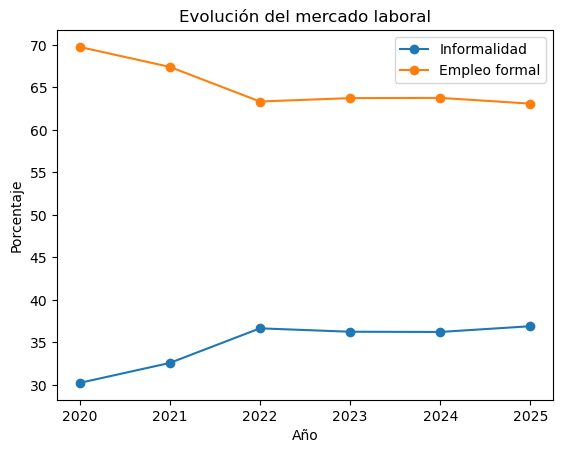

In [34]:
plt.figure()

plt.plot(df_informal_anual["anio"], df_informal_anual["tasa_informalidad"], marker="o", label="Informalidad")
plt.plot(df_informal_anual["anio"], df_informal_anual["tasa_empleo_formal"], marker="o", label="Empleo formal")

plt.title("Evolución del mercado laboral")
plt.xlabel("Año")
plt.ylabel("Porcentaje")

plt.legend()

plt.show()

Muestra claramente:

aumento de informalidad

caída del empleo formal

Comparación por año (barras)

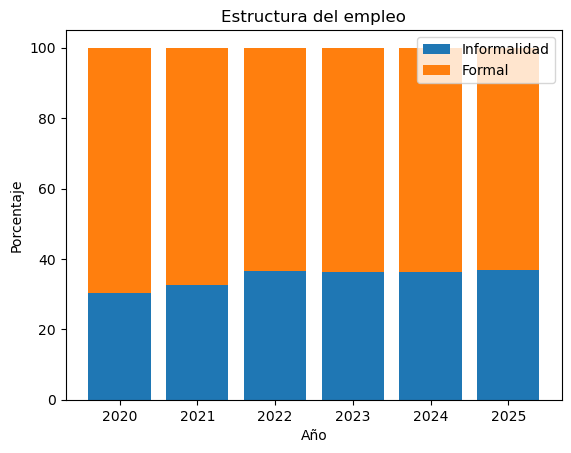

In [42]:
plt.figure()

plt.bar(df_informal_anual["anio"], df_informal_anual["tasa_informalidad"], label="Informalidad")
plt.bar(df_informal_anual["anio"], df_informal_anual["tasa_empleo_formal"], bottom=df_informal_anual["tasa_informalidad"], label="Formal")

plt.title("Estructura del empleo")
plt.xlabel("Año")
plt.ylabel("Porcentaje")

plt.legend()

plt.show()

Brecha entre empleo formal e informal

Esto es muy usado en análisis laboral.

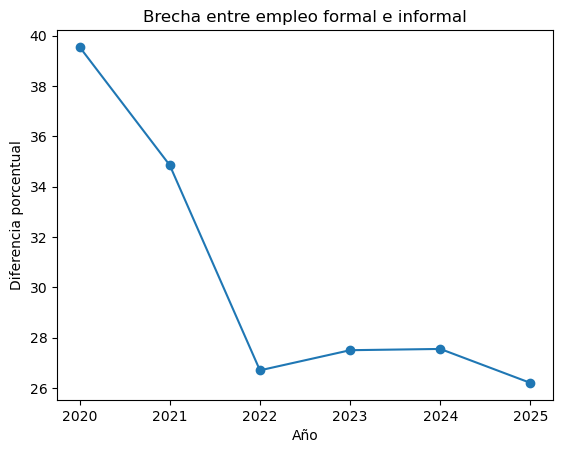

In [49]:
df_informal_anual["brecha"] = df_informal_anual["tasa_empleo_formal"] - df_informal_anual["tasa_informalidad"]

plt.figure()

plt.plot(df_informal_anual["anio"], df_informal_anual["brecha"], marker="o")

plt.title("Brecha entre empleo formal e informal")
plt.xlabel("Año")
plt.ylabel("Diferencia porcentual")

plt.show()

Te muestra si la estructura laboral se deteriora o mejora.

Gráfico de dispersión (muy analítico)

Esto muestra la relación entre informalidad y formalidad.

In [ ]:
plt.figure()

plt.scatter(df["tasa_informalidad"], df["tasa_empleo_formal"])

plt.title("Relación entre informalidad y empleo formal")
plt.xlabel("Tasa de informalidad")
plt.ylabel("Tasa de empleo formal")

plt.show()